# Spatial Analysis

Spatial analysis is the process of examining spatial data from a geographic perspective to identify patterns, relationships, and trends that can be used to solve problems and make predictions. Common techniques include:

- Exploratory spatial data analysis (ESDA)
- Spatial clustering
- Spatial regression and predictive modeling
- Spatial machine learning / GeoAI
- Point pattern analysis
- Spatial optimization
- Network analysis

Many of the commonly used spatial analysis tools can be found in the PySAL library. Given the extensive range of spatial analysis tasks, I will provide 2 examples below.
- Examine spatial autocorrelation and hot-spot analysis
- Network analysis + Accessibility

## Spatial Autocorrelation and Hot-spot analysis

### Census API

Import the packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np

from census import Census

First, get yourself a Census API key from [here](https://api.census.gov/data/key_signup.html). This will require you to put your affliation and your email. Then you need to activate your API key through the received email. You will then get a long key string to replace what I have here:

In [2]:
census_api_key = "0ed8bfc03db7e7bf1b990114c59b0840650c4fc7" #Replace this with yours

c = Census(census_api_key)

Then we can use a function to automatically download census data and make it into a nicely formatted Dataframe.

Below is an example to fetch the census tract level data for variables:

*   Total population (B01003_001E)
*   Median monthly housing costs (B25105_001E)
*   Numbers of people who drive (van, truck, car) to work (B08134_011E)


This data is from the American Community Survey (ACS) which is an annual effort to sample a small portion of US addresses through questionaries and aggregate data into census products over multiple years. Most often, the 5-year estimate ACS has good coverage, more details can be seen here: https://www.census.gov/data/developers/data-sets/acs-5year.html

Lookup table for variables: https://api.census.gov/data/2023/acs/acs5/variables.html

ChatGPT is able to help you to find the code for your variables of interest. For example with this prompt:

`"Using the census api python package, can you give me code for getting total population, median monthly housing costs, and number of people who drive to work, for all census tracts of Leon County in Florida?"`

You may want to check the returned variable code to make sure it is referring to the variable of interest.

In [3]:
# Sources: https://api.census.gov/data/2023/acs/acs5/variables.html
#Get Tract level data

county_code = "073"

#Get tract level data
leon_census = c.acs5.state_county_tract(fields = ('NAME', 'B01003_001E', 'B25105_001E', 'B08134_001E'), #variable names
                                      state_fips = '12', #state FIPS code for FL
                                      county_fips = county_code, #"*" means all counties in the state
                                      tract = "*", #"*" means all tracts in the counties/state
                                      year = 2023) # 2019 data


#Get County level data
"""
fl_census = c.acs5.state_county(fields = ('NAME', 'B01003_001E', 'B25105_001E', 'B08134_001E'), #variable names
                                      state_fips = '12', #state FIPS code for FL
                                      county_fips = "*", #"*" means all counties in the state
                                      year = 2019) # 2019 data
"""


'\nfl_census = c.acs5.state_county(fields = (\'NAME\', \'B01003_001E\', \'B25105_001E\', \'B08134_001E\'), #variable names\n                                      state_fips = \'12\', #state FIPS code for FL\n                                      county_fips = "*", #"*" means all counties in the state\n                                      year = 2019) # 2019 data\n'

Make the results a data frame.

In [4]:
leon_df = pd.DataFrame(leon_census)

In [5]:
leon_df

,NAME,B01003_001E,B25105_001E,B08134_001E,state,county,tract
0,Census Tract 2; Leon County; Florida,4112.0,1106.0,1982.0,12,073,000200
1,Census Tract 3.01; Leon County; Florida,1646.0,1314.0,692.0,12,073,000301
2,Census Tract 3.02; Leon County; Florida,2176.0,1235.0,903.0,12,073,000302
3,Census Tract 3.03; Leon County; Florida,4984.0,1247.0,1898.0,12,073,000303
4,Census Tract 4; Leon County; Florida,2829.0,1245.0,1213.0,12,073,000400
...,...,...,...,...,...,...,...
74,Census Tract 26.04; Leon County; Florida,2653.0,1038.0,926.0,12,073,002604
75,Census Tract 26.05; Leon County; Florida,5997.0,1788.0,2494.0,12,073,002605
76,Census Tract 26.06; Leon County; Florida,3074.0,1239.0,1378.0,12,073,002606
77,Census Tract 27.01; Leon County; Florida,4173.0,811.0,1752.0,12,073,002701


Rename column names.

In [6]:
leon_df = leon_df.rename(columns={
    "B01003_001E": "total_population",
    "B25105_001E": "monthly_housing_costs",
    "B08134_001E": "population_drive_to_work"
    })

In [7]:
leon_df.head()

,NAME,total_population,monthly_housing_costs,population_drive_to_work,state,county,tract
0,Census Tract 2; Leon County; Florida,4112.0,1106.0,1982.0,12,073,000200
1,Census Tract 3.01; Leon County; Florida,1646.0,1314.0,692.0,12,073,000301
2,Census Tract 3.02; Leon County; Florida,2176.0,1235.0,903.0,12,073,000302
3,Census Tract 3.03; Leon County; Florida,4984.0,1247.0,1898.0,12,073,000303
4,Census Tract 4; Leon County; Florida,2829.0,1245.0,1213.0,12,073,000400


In [8]:
leon_df.describe()

,total_population,monthly_housing_costs,population_drive_to_work
count,79.000000,7.900000e+01,79.000000
mean,3738.417722,-8.437544e+06,1641.670886
std,1398.039035,7.500601e+07,676.312678
min,971.000000,-6.666667e+08,386.000000
25%,2747.000000,1.100000e+03,1188.000000
50%,3632.000000,1.239000e+03,1568.000000
75%,4620.000000,1.391000e+03,2087.000000
max,8088.000000,2.120000e+03,3256.000000


Note: Census will denote missing values as -6.666667e+08

## FIPS Code

Each census unit is identified by the FIPS (Federal Information Processing Standard) code

<img src="https://blog.cdxtech.com/Blog/image.axd?picture=2012%2F8%2FFIPS+CODE.png">

And most of the administrative data from varisous agencies should have this code.

![image-2.png](https://learn.arcgis.com/en/related-concepts/GUID-D7AA4FD1-E7FE-49D7-9D11-07915C9ACC68-web.png)

# Obtain a boundary file from TIGER

A quick and easy way to directly fetch boundary from TIGER.

First we need to know the URL of the unit we want.

In [9]:
url = "https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_12_tract.zip"

In [10]:
fl_tracts = gpd.read_file(url)

<Axes: >

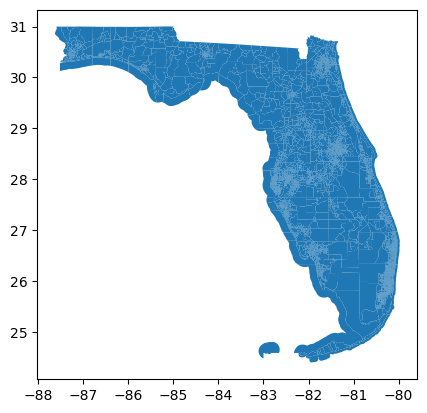

In [11]:
fl_tracts.plot()

In [12]:
leon_tracts = fl_tracts.loc[fl_tracts.COUNTYFP == county_code, ]

<Axes: >

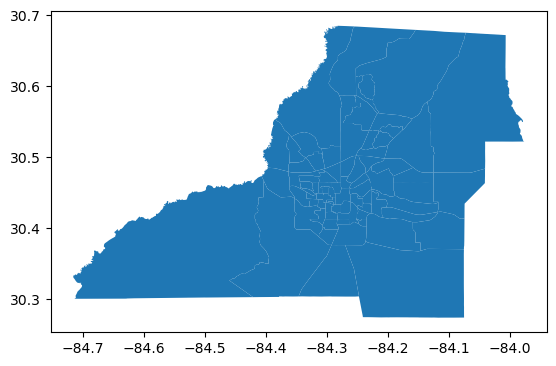

In [13]:
leon_tracts.plot()

In [14]:
leon_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
249,12,073,002512,12073002512,25.12,Census Tract 25.12,G5020,S,10826263,257080,+30.4703394,-084.1583913,"POLYGON ((-84.192 30.473, -84.192 30.473, -84...."
259,12,073,002006,12073002006,20.06,Census Tract 20.06,G5020,S,1421446,20036,+30.4331578,-084.3084544,"POLYGON ((-84.316 30.431, -84.316 30.431, -84...."
260,12,073,001300,12073001300,13,Census Tract 13,G5020,S,1472272,476,+30.4431469,-084.3007363,"POLYGON ((-84.307 30.441, -84.307 30.441, -84...."
261,12,073,001402,12073001402,14.02,Census Tract 14.02,G5020,S,1812691,5870,+30.4616925,-084.2991478,"POLYGON ((-84.314 30.464, -84.312 30.464, -84...."
263,12,073,000904,12073000904,9.04,Census Tract 9.04,G5020,S,2682418,3301,+30.4428390,-084.2393365,"POLYGON ((-84.251 30.448, -84.25 30.448, -84.2..."


The GeoDataFrame has FIPS code that we can use to join with the census data. Note that the `GEOID` concatenates state and county and tract code together into a long code.

To make a consistent key, we need to create a new column in the census dataframe `leon_df` exactly the same as the `GEOID` in `fl_tracts`.

In [15]:
leon_df.head()

,NAME,total_population,monthly_housing_costs,population_drive_to_work,state,county,tract
0,Census Tract 2; Leon County; Florida,4112.0,1106.0,1982.0,12,073,000200
1,Census Tract 3.01; Leon County; Florida,1646.0,1314.0,692.0,12,073,000301
2,Census Tract 3.02; Leon County; Florida,2176.0,1235.0,903.0,12,073,000302
3,Census Tract 3.03; Leon County; Florida,4984.0,1247.0,1898.0,12,073,000303
4,Census Tract 4; Leon County; Florida,2829.0,1245.0,1213.0,12,073,000400


In [16]:
leon_df["GEOID"] = leon_df["state"] + leon_df["county"] + leon_df["tract"]

In [17]:
leon_df["GEOID"]

0     12073000200
1     12073000301
2     12073000302
3     12073000303
4     12073000400
         ...     
74    12073002604
75    12073002605
76    12073002606
77    12073002701
78    12073002702
Name: GEOID, Length: 79, dtype: object

Merge two dataframes based on the same key `GEOID`.

In [18]:
leon_df

,NAME,total_population,monthly_housing_costs,population_drive_to_work,state,county,tract,GEOID
0,Census Tract 2; Leon County; Florida,4112.0,1106.0,1982.0,12,073,000200,12073000200
1,Census Tract 3.01; Leon County; Florida,1646.0,1314.0,692.0,12,073,000301,12073000301
2,Census Tract 3.02; Leon County; Florida,2176.0,1235.0,903.0,12,073,000302,12073000302
3,Census Tract 3.03; Leon County; Florida,4984.0,1247.0,1898.0,12,073,000303,12073000303
4,Census Tract 4; Leon County; Florida,2829.0,1245.0,1213.0,12,073,000400,12073000400
...,...,...,...,...,...,...,...,...
74,Census Tract 26.04; Leon County; Florida,2653.0,1038.0,926.0,12,073,002604,12073002604
75,Census Tract 26.05; Leon County; Florida,5997.0,1788.0,2494.0,12,073,002605,12073002605
76,Census Tract 26.06; Leon County; Florida,3074.0,1239.0,1378.0,12,073,002606,12073002606
77,Census Tract 27.01; Leon County; Florida,4173.0,811.0,1752.0,12,073,002701,12073002701


In [19]:
leon_tracts_df = pd.merge(leon_tracts, leon_df,on="GEOID")

In [20]:
leon_tracts_df.shape

(79, 20)

In [21]:
leon_tracts_df

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,NAME_y,total_population,monthly_housing_costs,population_drive_to_work,state,county,tract
0,12,073,002512,12073002512,25.12,Census Tract 25.12,G5020,S,10826263,257080,+30.4703394,-084.1583913,"POLYGON ((-84.192 30.473, -84.192 30.473, -84....",Census Tract 25.12; Leon County; Florida,3852.0,1581.0,1372.0,12,073,002512
1,12,073,002006,12073002006,20.06,Census Tract 20.06,G5020,S,1421446,20036,+30.4331578,-084.3084544,"POLYGON ((-84.316 30.431, -84.316 30.431, -84....",Census Tract 20.06; Leon County; Florida,3959.0,1129.0,1852.0,12,073,002006
2,12,073,001300,12073001300,13,Census Tract 13,G5020,S,1472272,476,+30.4431469,-084.3007363,"POLYGON ((-84.307 30.441, -84.307 30.441, -84....",Census Tract 13; Leon County; Florida,8088.0,-666666666.0,1568.0,12,073,001300
3,12,073,001402,12073001402,14.02,Census Tract 14.02,G5020,S,1812691,5870,+30.4616925,-084.2991478,"POLYGON ((-84.314 30.464, -84.312 30.464, -84....",Census Tract 14.02; Leon County; Florida,5146.0,1295.0,2605.0,12,073,001402
4,12,073,000904,12073000904,9.04,Census Tract 9.04,G5020,S,2682418,3301,+30.4428390,-084.2393365,"POLYGON ((-84.251 30.448, -84.25 30.448, -84.2...",Census Tract 9.04; Leon County; Florida,3746.0,1182.0,2317.0,12,073,000904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,12,073,002702,12073002702,27.02,Census Tract 27.02,G5020,S,367819243,10282850,+30.3887591,-084.5489241,"POLYGON ((-84.715 30.331, -84.715 30.331, -84....",Census Tract 27.02; Leon County; Florida,3988.0,831.0,1561.0,12,073,002702
75,12,073,002701,12073002701,27.01,Census Tract 27.01,G5020,S,133171337,2960416,+30.3672705,-084.3848623,"POLYGON ((-84.459 30.326, -84.459 30.326, -84....",Census Tract 27.01; Leon County; Florida,4173.0,811.0,1752.0,12,073,002701
76,12,073,002413,12073002413,24.13,Census Tract 24.13,G5020,S,119935419,16709791,+30.6242927,-084.1603601,"POLYGON ((-84.253 30.625, -84.252 30.625, -84....",Census Tract 24.13; Leon County; Florida,3124.0,1900.0,1339.0,12,073,002413
77,12,073,002414,12073002414,24.14,Census Tract 24.14,G5020,S,5086539,341812,+30.5239783,-084.2085520,"POLYGON ((-84.225 30.518, -84.225 30.519, -84....",Census Tract 24.14; Leon County; Florida,4716.0,1239.0,1823.0,12,073,002414


Text(0.5, 1.0, 'Monthly housing costs ($)')

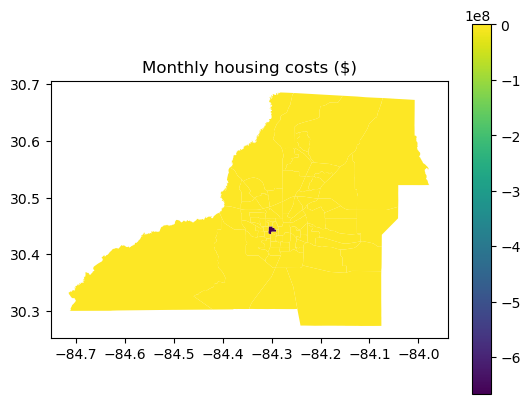

In [22]:
leon_tracts_df.plot(column="monthly_housing_costs",legend=True)

plt.title("Monthly housing costs ($)")

That little dark polygon is where there is no data and coded as -66666666, now we can do something to it. There are multiple strategies to handle missing value. Here, we just make it NA, then replace it with the average value across the map.

In [23]:
leon_tracts_df["monthly_housing_costs"] = leon_tracts_df["monthly_housing_costs"].replace(-666666666.0, np.nan)

mean = leon_tracts_df["monthly_housing_costs"].mean()

leon_tracts_df["monthly_housing_costs"] = leon_tracts_df["monthly_housing_costs"].replace(np.nan, mean)


Text(0.5, 1.0, 'Monthly housing costs ($)')

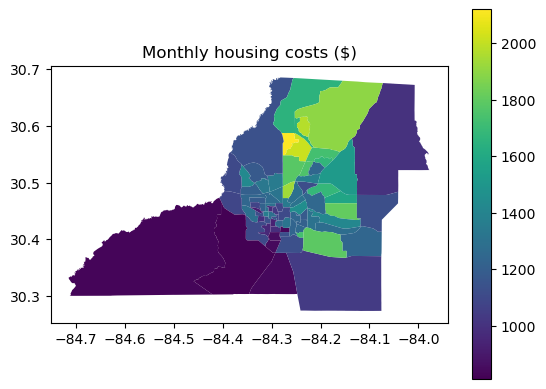

In [24]:
leon_tracts_df.plot(column="monthly_housing_costs",legend=True)

plt.title("Monthly housing costs ($)")

Now let's look at the other variable, population drive to work. Here we can calculate the % of people drive to work and make a new column in the dataframe.

In [25]:
leon_tracts_df["pct_drive"] = leon_tracts_df["population_drive_to_work"]/leon_tracts_df["total_population"]*100

<Axes: >

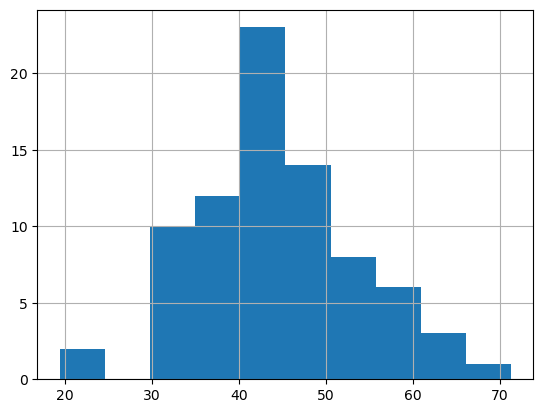

In [26]:
leon_tracts_df["pct_drive"].hist()

Text(0.5, 1.0, '% of People drive to work')

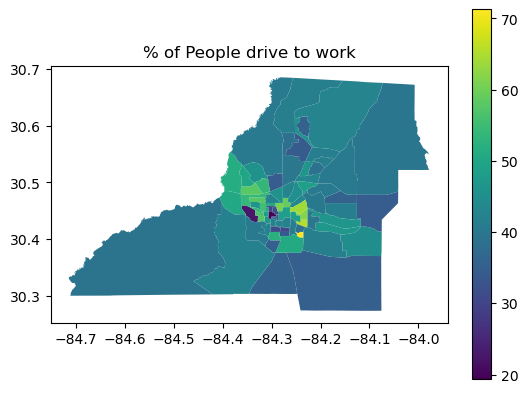

In [27]:
leon_tracts_df.plot(column="pct_drive",legend=True)

plt.title("% of People drive to work")

A simple scatterplot showing a positive correlation between the two variables.

Text(0, 0.5, 'Monthly Housing Costs')

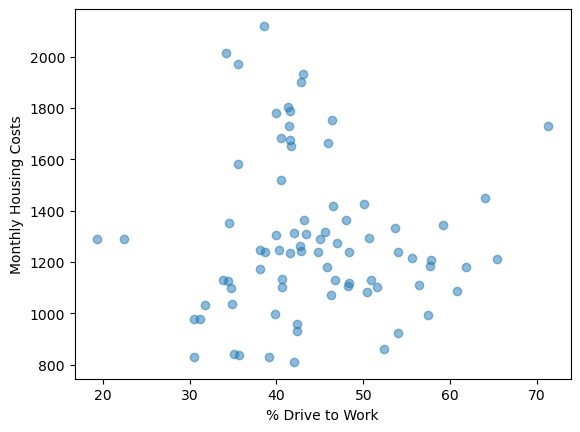

In [28]:
plt.scatter(leon_tracts_df["pct_drive"], leon_tracts_df["monthly_housing_costs"],alpha=0.5)

plt.xlabel("% Drive to Work")
plt.ylabel("Monthly Housing Costs")

We don't see much correlation from the plot.

## Autocorrelation - hotspot analysis

- Global Moran's I
- Moran Scatterplot
- Local Moran's I (LISA)


If you have `pysal` installed, you may not need to install these

In [29]:
#pip install -q splot

In [30]:
#pip install -q libpysal

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from libpysal.weights.contiguity import Queen

from splot.esda import moran_scatterplot,plot_moran,lisa_cluster
from esda.moran import Moran, Moran_Local

import splot

## Global Moran's I and p-value

Moran’s I is a measure of spatial autocorrelation — that is, it tells you whether similar values tend to occur near each other in space.

![image-2.png](https://desktop.arcgis.com/en/arcmap/latest/tools/spatial-statistics-toolbox/GUID-5CCEE7E5-839C-46E8-A88B-FCD02F07B209-web.gif)

Specify a weight matrix to indicate the neighborhood structure. To review the concept of spatial autocorrelation and statistics, please see here: https://geographicdata.science/book/notebooks/06_spatial_autocorrelation.html

In [32]:
w = Queen.from_dataframe(leon_tracts_df) #Generate W matrix using Queen contiguity


w.transform = 'r' #Row-standardization of the weight matrix

/var/folders/mp/9px298sd6vs8xccb_3sql0dr0000gp/T/ipykernel_34461/3881035560.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(leon_tracts_df) #Generate W matrix using Queen contiguity


Calculate Moran's I

In [33]:
from esda.moran import Moran

housing_costs = leon_tracts_df['monthly_housing_costs'].values #Get the data we are interested.

global_moran = Moran(housing_costs, w)

global_moran.I

0.5084737632660357

Like correlation coefficient, this indicates a strong positive spatial autocorrelation.

p-value

In [34]:
global_moran.p_sim # P value based on permutation tests

0.001

This is indicating that the observed positive spatial autocorrelation of the median housing costs map is statistically significant (p<0.05).

## Moran Scatterplot

/Users/ziqili/anaconda3/lib/python3.11/site-packages/splot/_viz_esda_mpl.py:354: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sbn.kdeplot(moran.sim, shade=shade, color=color, ax=ax, **kwargs)
/Users/ziqili/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.51', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.51)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

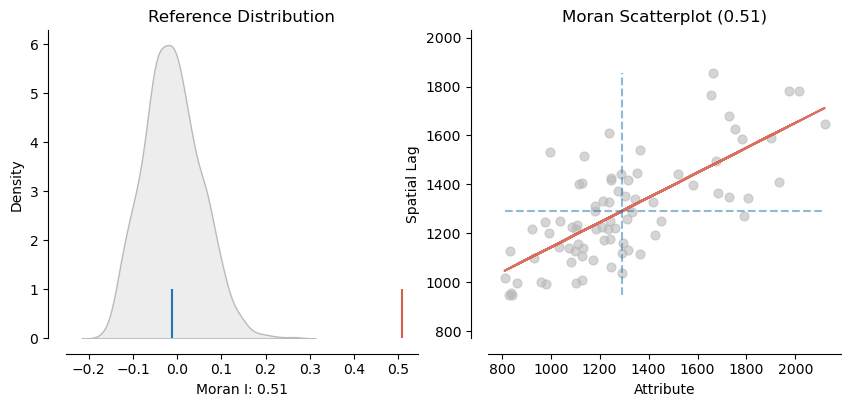

In [35]:
from splot.esda import plot_moran

plot_moran(global_moran, 
           zstandard=False, #True the data will be normalized (mean removed and divided by std)
           figsize=(10,4)
          )

The left is the null sampling distribution of Moran's I under assumption of spatial randomness. The blue bar is the position of expected Moran's I value (-1/(n-1)), and the red bar marks the observed Moran's I value (0.51).

The right is a Moran Scatterplot where the x axis is the current location's housing costs, and the y-axis is the nearby housing costs.

## Local Moran's I (LISA)

Generate a better Moran Scatterplot with significance of the local moran's Is.

Color code each county with the quadrant it falls into.
- Red: HH (High values near high values) - Hotspot
- Light Blue: LH (Low values near high values)
- Yellow: HL (High values near low values)
- Blue: LL - (low values near low values) - Cold spot

/Users/ziqili/anaconda3/lib/python3.11/site-packages/esda/moran.py:1084: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


Text(0, 0.5, 'Averaged Housing Costs in the Close Neighborhoods')

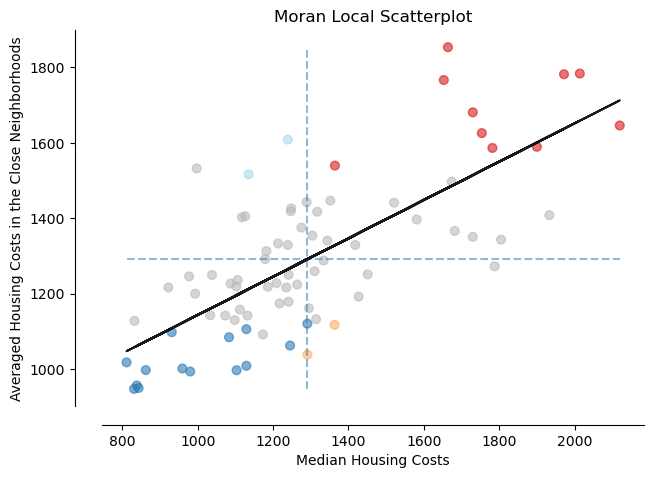

In [36]:
from splot.esda import moran_scatterplot
from esda.moran import Moran_Local

# calculate Moran_Local and plot
moran_local = Moran_Local(housing_costs, w)

fig, ax = moran_scatterplot(moran_local, zstandard=False, p=0.05)

#Labelling
ax.set_xlabel('Median Housing Costs')
ax.set_ylabel('Averaged Housing Costs in the Close Neighborhoods')


(<Figure size 600x600 with 1 Axes>, <Axes: >)

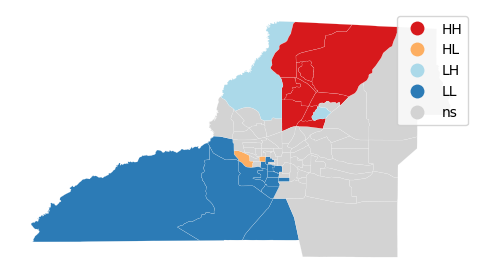

In [37]:
from splot.esda import lisa_cluster

lisa_cluster(moran_loc=moran_local, 
             gdf=leon_tracts_df, 
             p = 0.05, # the level of p-value threshold to mask for non-significance
             figsize = (6,6))

### Statistical modelling

One of the important tasks in data science is to model or predict an outcome by building a statistical model. The simplest form of such a model is linear regression, which can become more complex and evolve into a machine learning model.

The typical form of a statistical model is one in which y represents the outcome, and X₁, X₂, … are the predictors (also known as covariates, explanatory variables, or independent variables).

`y = f(X1, X2, X3, ...)`

Here I build a simple linear regression to examine the relationship between `pct_drive` and `housing costs` and `population density` using `statsmodels`.

In [38]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

leon_tracts_df.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME_x', 'NAMELSAD',
       'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'geometry', 'NAME_y', 'total_population', 'monthly_housing_costs',
       'population_drive_to_work', 'state', 'county', 'tract', 'pct_drive'],
      dtype='object')

In [39]:
leon_tracts_df["pop_density"] = leon_tracts_df.total_population / (leon_tracts_df.ALAND / 2_589_988.110336)

In [40]:
# Fit OLS regression using R-style formula
model = smf.ols("pct_drive ~ monthly_housing_costs + pop_density", data=leon_tracts_df).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              pct_drive   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                   0.06075
Date:                Thu, 23 Oct 2025   Prob (F-statistic):              0.941
Time:                        09:43:55   Log-Likelihood:                -288.42
No. Observations:                  79   AIC:                             582.8
Df Residuals:                      76   BIC:                             590.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                45.34

Above is a typical regression output summary which indicates model diagnostics, goodness of fit, and regression coefficients. 

The regression model shows that `monthly_housing_costs` and `pop_density` do not have a statistically significant relationship with `pct_drive` by examining the P>|t| (p-value) is smaller than 0.05.

## Network & Accessibility Analysis

`OSMnx` is a powerful open-source Python library for working with street networks, buildings, and other geospatial data from OpenStreetMap (OSM).


It makes it easy to download, analyze, visualize, and model real-world urban infrastructure directly from OSM — without needing to manually handle shapefiles or APIs.

In [41]:
#pip install osmnx

In [42]:
import osmnx as ox
import networkx as nx #osmnx is built upon networkx which is a generic network package.
import geopandas as gpd

from shapely.geometry import Point
import matplotlib.pyplot as plt

#### Geocoding service 

`osmnx` provides free geocoding service (through OSM) which transforms text address into location coordinates.

In [43]:
ox.geocode("113 Collegiate Loop, Tallahassee, Florida, USA")

(30.4416527, -84.2955294)

#### Fetch road network data

In [44]:
import osmnx as ox
import contextily as cx
import matplotlib.pyplot as plt

# Download Tallahassee’s road network (driving)
city = "Tallahassee, Florida, USA"

G = ox.graph_from_place(city, network_type="drive", simplify=True)

nodes, edges = ox.graph_to_gdfs(G)


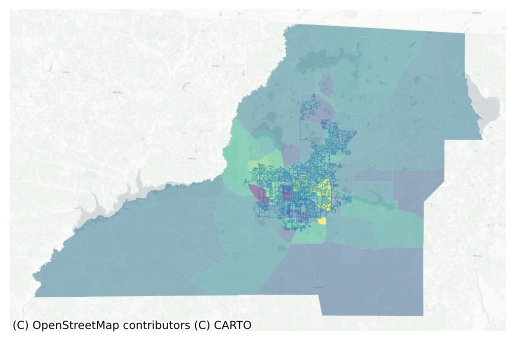

In [45]:
fig, ax = plt.subplots()

# 3) Plot the network and add a basemap underneath
leon_tracts_df.plot(column="pct_drive", alpha=0.5, ax=ax)

edges.plot(ax=ax,lw=0.1)

# Add a light basemap (you can swap to Stamen/Toner, etc.)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron,crs=4326,zoom=12)

ax.set_axis_off()


In [46]:
leon_tract = leon_tracts_df.copy()

In [47]:
# Alternatively, we can get road based on a polygon

# convert crs
tracts_wgs84 = leon_tract.to_crs(4326)

# get the study area as a polygon
study_polygon = tracts_wgs84.union_all()

# Pull the drive network for the polygon
G = ox.graph_from_polygon(study_polygon, network_type="drive")

# Add speeds and travel time (seconds) to each edge
G = ox.add_edge_speeds(G)           # impute speeds where missing based on highway type
G = ox.add_edge_travel_times(G)     # adds 'travel_time' in seconds


In [48]:
nodes, edges = ox.graph_to_gdfs(G)

<Axes: >

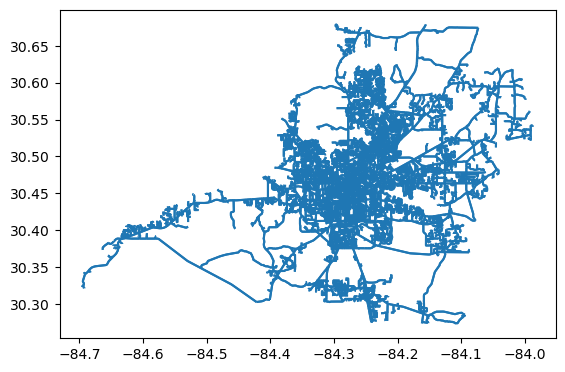

In [49]:
edges.plot()

For any distance based operation we need to convert them into projected system, here i use Web Mercator.

In [50]:
G3857 = ox.project_graph(G, to_crs="EPSG:3857")

### Accessibility analysis

Here I am trying to replicate an analysis similar to:

https://github.com/pysal/access/blob/main/notebooks/5_compute_access_scores_joined_census_tracts.ipynb

Next we need to make a tract - tract travel time matrix

In [51]:
# Get centroids of tracts

tracts_internal = leon_tract.copy()
tracts_internal = tracts_internal.to_crs(3857)  # project to meters for geometry ops

pts = tracts_internal.centroid

# Build an ID series for labeling

tract_ids = leon_tract["GEOID"].astype(str).tolist()


# Snap each tract point to its nearest graph node

xs = [p.x for p in pts]
ys = [p.y for p in pts]
nearest_nodes = ox.distance.nearest_nodes(G3857, xs, ys)  # returns a list aligned to tract_ids

# We'll keep a mapping: tract_id -> node
tract2node = dict(zip(tract_ids, nearest_nodes))



# Compute tract-to-tract travel-time matrix (minutes)

# We’ll run single-source Dijkstra from each tract node, but only keep distances to other tract nodes.
node_set = set(nearest_nodes)
id_list = tract_ids  # stable ordering
n = len(id_list)

# Initialize matrix with NaNs; fill with minutes
mat = np.full((n, n), np.nan, dtype=float)

for i, src_id in enumerate(id_list):
    src_node = tract2node[src_id]
    # Dijkstra on travel_time (in seconds)
    # returns dict: node -> travel_time_seconds
    dist_sec = nx.single_source_dijkstra_path_length(G3857, source=src_node, weight='travel_time')
    # Pull just our target nodes
    for j, dst_id in enumerate(id_list):
        dst_node = tract2node[dst_id]
        if dst_node in dist_sec:
            mat[i, j] = dist_sec[dst_node] / 60.0  # minutes

# Wrap in a tidy DataFrame
cost_minutes = pd.DataFrame(mat, index=id_list, columns=id_list)


In [52]:
cost_minutes

,12073002512,12073002006,12073001300,12073001402,12073000904,12073000905,12073002005,12073002103,12073002513,12073001901,...,12073002604,12073002605,12073001902,12073002208,12073002411,12073002702,12073002701,12073002413,12073002414,12073002207
12073002512,0.000000,17.592009,15.582893,16.647163,10.641786,12.016461,17.348345,17.854974,4.586343,19.538139,...,33.645870,17.340641,20.318980,21.538973,38.070686,42.934173,27.238004,23.449733,18.330306,18.046156
12073002006,17.471194,0.000000,3.793730,3.877384,9.081706,7.837977,2.409644,3.455618,18.128816,4.188678,...,28.225006,14.793626,5.327284,14.416400,34.871550,28.114381,12.418212,23.002541,19.373693,10.923583
12073001300,15.466051,3.836271,0.000000,3.136309,7.962966,7.272302,3.048080,3.554710,16.123673,6.932367,...,28.958179,14.227950,8.070972,12.840390,32.866407,30.858069,15.161900,20.997398,17.368550,9.347573
12073001402,16.679923,3.879902,3.142591,0.000000,9.176838,8.486174,3.091711,2.718921,17.337545,6.975998,...,30.172052,15.441823,8.114603,11.398720,31.440459,30.901700,15.205532,20.550618,17.503297,7.905903
12073000904,10.688063,9.308455,8.043729,9.107999,0.000000,2.934651,9.809181,10.315810,11.345685,10.783231,...,28.655788,8.326933,11.564072,16.595964,33.152417,34.179265,18.483096,18.531464,12.875114,13.103147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12073002702,42.907343,28.114381,30.823283,30.906938,34.169967,32.926238,29.536674,30.965972,43.564965,25.928064,...,45.447690,33.460167,25.329079,39.886647,61.053120,0.000000,15.696169,49.088686,44.809842,38.127476
12073002701,27.211174,12.418212,15.127114,15.210769,18.473798,17.230069,13.840505,15.269803,27.868796,10.231896,...,29.751521,17.763998,9.632910,24.381873,45.356951,15.696169,0.000000,33.392517,29.113673,22.431307
12073002413,22.904215,23.148754,21.028941,20.199094,18.469906,19.844581,22.429251,21.505473,24.693461,25.441107,...,45.422664,25.168760,26.579713,24.030419,14.620953,49.199030,33.502861,0.000000,14.680969,20.537602
12073002414,18.361744,19.617490,17.608374,17.218001,12.795811,14.170486,19.373825,18.524380,19.019366,21.563620,...,39.823520,19.494665,22.344461,21.049327,29.211995,44.959654,29.263485,14.591043,0.000000,17.556510


In [53]:

# Reshape the tract-to-tract matrix into a long table
# 'cost_minutes' is a square DataFrame with origins as index, destinations as columns.
# We'll "stack" it into a long form.

travel_time_long = (
    cost_minutes
    .stack()                       # turns wide to long
    .reset_index()                 # convert index to columns
    .rename(columns={
        'level_0': 'origin',
        'level_1': 'destination',
        0: 'travel_time_min'
    })
)

# Remove self-pairs (same tract)
leon_cost_matrix = travel_time_long[travel_time_long['origin'] != travel_time_long['destination']]

# (Optional) Drop missing values if any
#leon_cost_matrix = travel_time_long.dropna(subset=['travel_time_min']).reset_index(drop=True)


leon_cost_matrix.head()

,origin,destination,travel_time_min
1,12073002512,12073002006,17.592009
2,12073002512,12073001300,15.582893
3,12073002512,12073001402,16.647163
4,12073002512,12073000904,10.641786
5,12073002512,12073000905,12.016461


array([[<Axes: title={'center': 'travel_time_min'}>]], dtype=object)

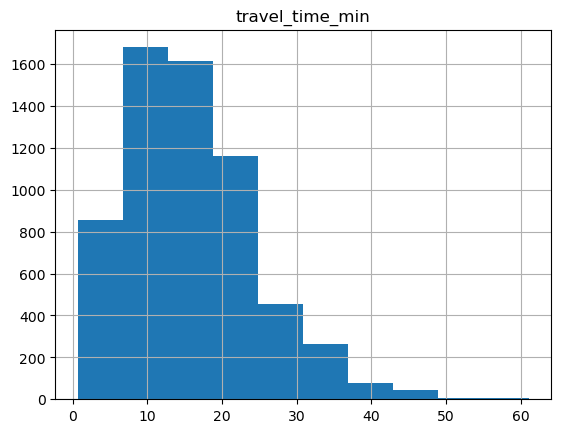

In [54]:
leon_cost_matrix.hist()

Get hospital data from: https://geodata.dep.state.fl.us/datasets/health-care-facilities/explore

In [55]:
fl_hospitals = gpd.read_file("https://raw.githubusercontent.com/Ziqi-Li/GIS5103/refs/heads/fall25/data/fl_hospitals.geojson")

<Axes: >

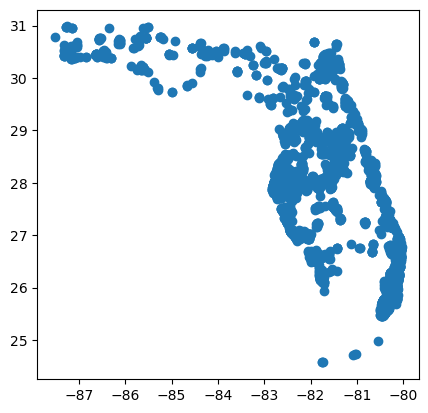

In [56]:
fl_hospitals.plot()

In [57]:
fl_hospitals = fl_hospitals.to_crs(epsg=3857)

In [58]:
leon_tracts_df = leon_tracts_df.to_crs(epsg=3857)

In [59]:
leon_tract = leon_tract.to_crs(epsg=3857)

In [60]:
leon_hospitals = gpd.sjoin(
    fl_hospitals,
    leon_tract,
    how="inner",
    predicate="within"   # only points that are strictly inside tracts
)

<Axes: >

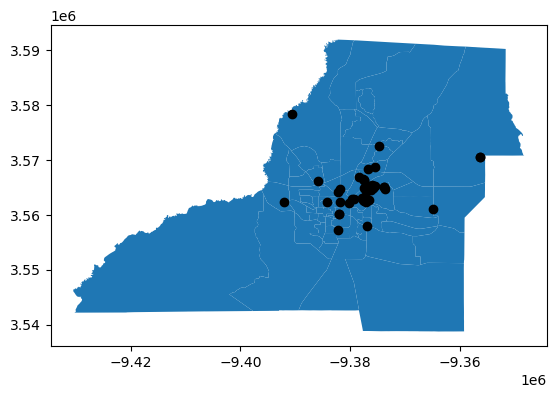

In [61]:
ax = leon_tract.plot()

leon_hospitals.plot(ax=ax,color="black")

In [62]:
leon_hospitals.columns

Index(['OBJECTID', 'Name', 'Address', 'City', 'Zip', 'COUNTY', 'Notes', 'X',
       'Y', 'LONGLAT', 'USNG', 'OWNERSHIP', 'PARCELID', 'FACILITY_TYPE',
       'TTL_BEDS', 'Asset_Elevation', 'Owned_Maintained', 'Asset',
       'Asset_Sub_Type', 'Asset_Type', 'Asset_Group', 'Asset_Relevancy',
       'Asset_ID', 'Municipality', 'Water_Management_District',
       'Souce_Dataset_Entity', 'Souce_Dataset_Name', 'Source_Asset_ID',
       'Restricted_Public_Disclosure', 'Regional_Planning_Council',
       'FDEP_Regulatory_District', 'RCP_Region', 'FDOT_District',
       'House_District_Number', 'Senate_District_Number', 'CTF_RL_2020',
       'CTF_RL_2040_IL', 'CTF_RL_2040_INT', 'CTF_RL_2070_IL',
       'CTF_RL_2070_INT', 'SSF_RL_100YR_CURR', 'SSF_RL_100YR_2040_IL',
       'SSF_RL_100YR_2040_INT', 'SSF_RL_100YR_2070_IL',
       'SSF_RL_100YR_2070_INT', 'SSF_RL_500YR_CURR', 'SSF_RL_500YR_2040_IL',
       'SSF_RL_500YR_2040_INT', 'SSF_RL_500YR_2070_IL',
       'SSF_RL_500YR_2070_INT', 'RIF_RL_100YR

In [63]:
from access import Access,weights

leon_hospital_access = Access(
    demand_df=leon_tracts_df,
    demand_index="GEOID",
    demand_value="total_population",
    supply_df=leon_hospitals,
    supply_index="GEOID",
    cost_df=leon_cost_matrix,
    cost_origin="origin",
    cost_dest="destination",
    cost_name="travel_time_min",
)

access INFO     :: Warning: A supply value was not provided, so a default
                             supply value of 1 was created in the column named "value".
                             Note that without a supply value, you cannot use any of the
                             floating catchment area methods.


In [64]:
gravity = weights.gravity(scale=60, alpha=-1)

leon_hospital_access.weighted_catchment(name="gravity", weight_fn=gravity)

,gravity_value
GEOID,
12073000200,482.729800
12073000301,405.791577
12073000302,345.247328
12073000303,381.769905
12073000400,369.896037
...,...
12073002604,90.464592
12073002605,219.332917
12073002606,147.594717


<Axes: >

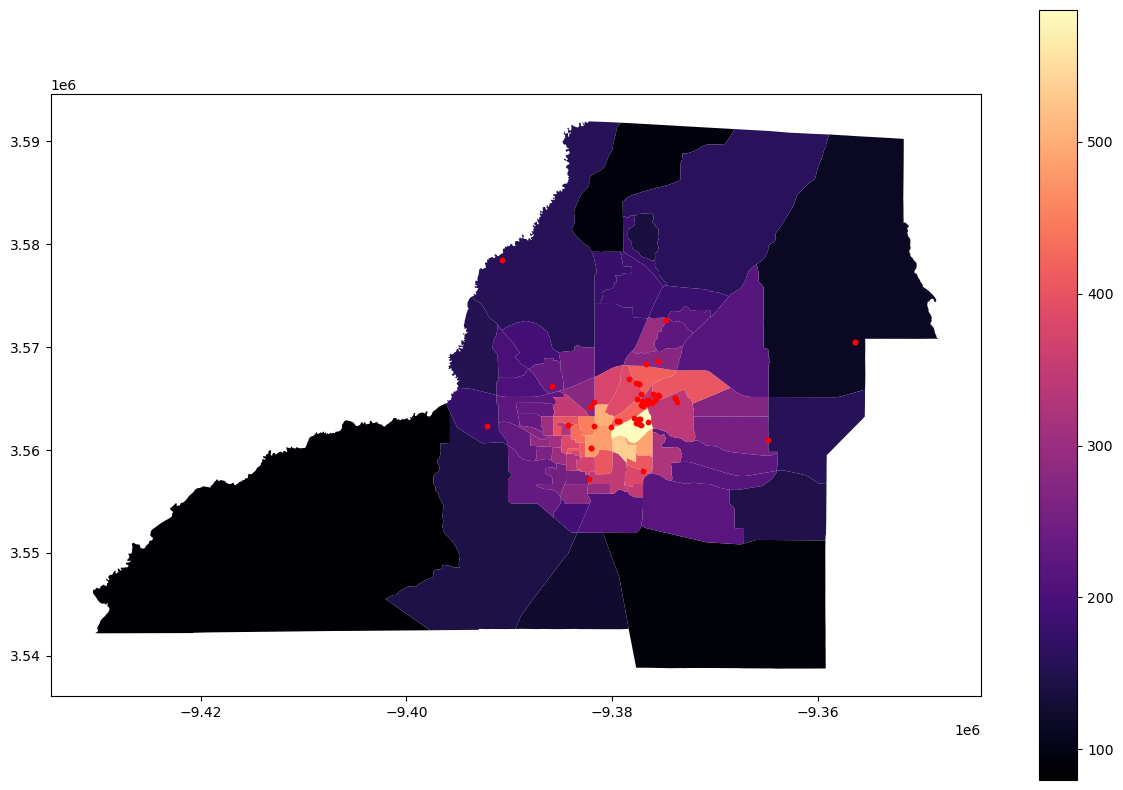

In [65]:

leon_map = (
        leon_tracts_df[["GEOID", "geometry"]]
        .set_index("GEOID")
        .join(leon_hospital_access.access_df, how="inner")
    )

ax = leon_map.plot(
        "gravity_value",
        legend=True,
        figsize=(15, 10),
        cmap="magma",
        markersize=0.5,
        alpha=1,
    )

leon_hospitals.plot(ax=ax, markersize=10, color="red")